MEASURING THE IMPACT OF CT SKILLS ON SUCCESS 

In [29]:
import pandas as pd

dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)
df.loc[75, 'A2.1-1.6'] = None

temel_sutunlar = ['M1-1', 'PA1-1', 'D1-1', 'A2.1-1.6', 'Nota Examen']
korelasyon = df[temel_sutunlar].corr()['Nota Examen'].drop('Nota Examen')

# --- ADIM 4: CT BECERİLERİNİN NOTA ETKİ YÜZDESİ (R-KARE) ---
print("--- CT BECERİLERİNİN FİNAL NOTUNU BELİRLEME YÜZDELERİ (%) ---")
etki_yuzdesi = (korelasyon ** 2) * 100
print(etki_yuzdesi.sort_values(ascending=False).round(1))

--- CT BECERİLERİNİN FİNAL NOTUNU BELİRLEME YÜZDELERİ (%) ---
A2.1-1.6    43.7
M1-1        20.3
D1-1        19.5
PA1-1       17.5
Name: Nota Examen, dtype: float64


OVERVIEW OF THE STUDENT COHORT 

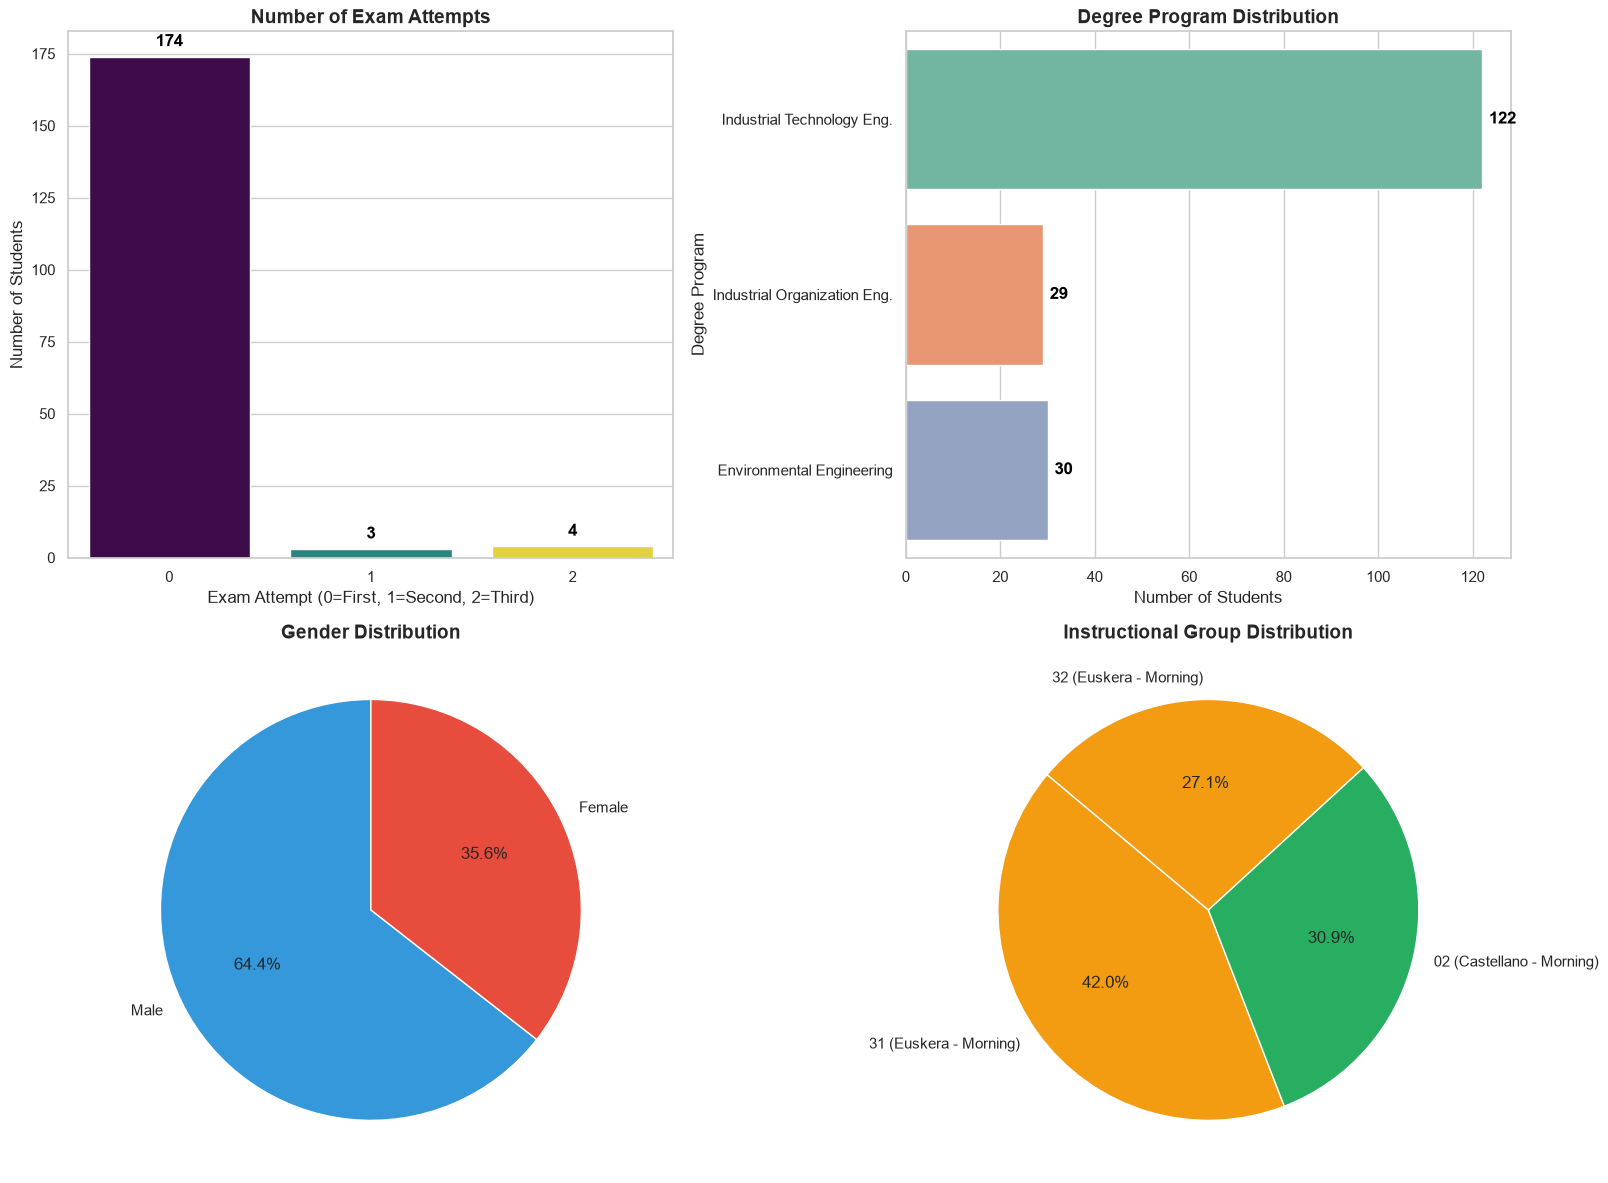

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- VERİ YÜKLEME ---
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# --- İNGİLİZCE VERİ ÇEVİRİSİ (Veri içindeki etiketleri değiştiriyoruz) ---
# Bölüm (Titulación) isimlerini İngilizceye çevir
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 12))

# 1. Grafik: Sınava Kaçıncı Kez Giriyorlar? (Sol Üst)
plt.subplot(2, 2, 1)
if 'CONVOCATORIAS' in df.columns:
    ax1 = sns.countplot(data=df, x='CONVOCATORIAS', hue='CONVOCATORIAS', palette='viridis', legend=False)
    plt.title("Number of Exam Attempts", fontweight='bold', fontsize=14)
    plt.ylabel("Number of Students")
    plt.xlabel("Exam Attempt (0=First, 1=Second, 2=Third)")
    
    # ÇUBUKLARIN ÜZERİNE SAYILARI (ETİKETLERİ) YAZDIRMA DÖNGÜSÜ
    for p in ax1.patches:
        ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# 2. Grafik: Bölüm Dağılımı (Sağ Üst)
bolum_sutunu = 'TITULACIÓN' 
plt.subplot(2, 2, 2)
if bolum_sutunu in df.columns:
    ax2 = sns.countplot(data=df, y=bolum_sutunu, hue=bolum_sutunu, palette='Set2', legend=False)
    plt.title("Degree Program Distribution", fontweight='bold', fontsize=14)
    plt.xlabel("Number of Students")
    plt.ylabel("Degree Program")
    
    # BÖLÜM ÇUBUKLARININ YANINA DA SAYILARI YAZDIRIYORUZ
    for p in ax2.patches:
        ax2.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=12, fontweight='bold', color='black', xytext=(5, 0), textcoords='offset points')

# 3. Grafik: Cinsiyet Dağılımı (Sol Alt) - AKILLI ARAMA
plt.subplot(2, 2, 3)
cinsiyet_sutun_adaylari = [col for col in df.columns if 'CHICO' in str(col).upper()]

if cinsiyet_sutun_adaylari:
    gercek_cinsiyet_sutunu = cinsiyet_sutun_adaylari[0]
    # Cinsiyet etiketlerini İngilizceye eşliyoruz
    df['Cinsiyet_Etiket'] = df[gercek_cinsiyet_sutunu].map({0.0: 'Male', 1.0: 'Female'})
    cinsiyet_sayilari = df['Cinsiyet_Etiket'].value_counts()
    plt.pie(cinsiyet_sayilari, labels=cinsiyet_sayilari.index, autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
    plt.title("Gender Distribution", fontweight='bold', fontsize=14)

# 4. Grafik: Castellano / Euskera Grup Dağılımı (Sağ Alt)
grup_sutunu = 'GRUPO' 
plt.subplot(2, 2, 4)
if grup_sutunu in df.columns:
    grup_sayilari = df[grup_sutunu].value_counts()
    
    # "Mañana" kelimesini İngilizce "Morning" olarak değiştiren liste üreteci
    ingilizce_grup_etiketleri = [str(label).replace('Mañana', 'Morning') for label in grup_sayilari.index]
    
    plt.pie(grup_sayilari, labels=ingilizce_grup_etiketleri, autopct='%1.1f%%', startangle=140, colors=['#f39c12', '#27ae60'])
    plt.title("Instructional Group Distribution", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

CORRELATION MATRIX OF COMPUTATIONAL THINKING SKILLS AND FINAL EXAM SCORE

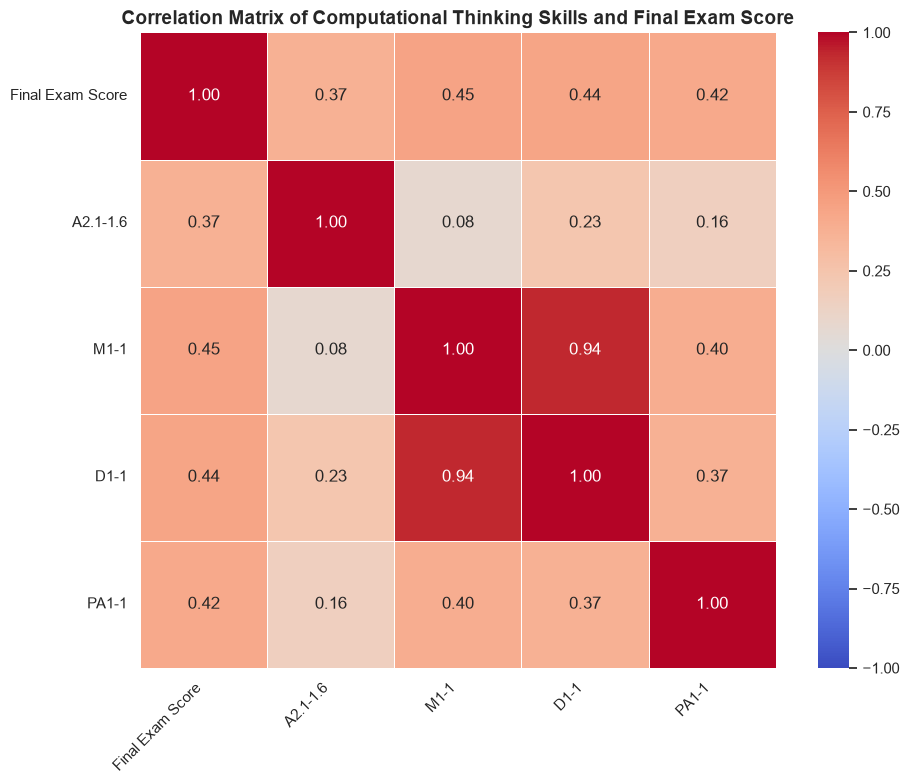

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- VERİ YÜKLEME ---
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# --- İNGİLİZCE VERİ ÇEVİRİSİ ---
# "Nota Examen" sütununu eksenlerde doğru görünmesi için İngilizceye çeviriyoruz
df = df.rename(columns={'Nota Examen': 'Final Exam Score'})

# Sadece incelemek istediğimiz SAYISAL sütunları seçiyoruz (Güncel İngilizce isimle)
ilgili_sutunlar = ['Final Exam Score', 'A2.1-1.6', 'M1-1', 'D1-1', 'PA1-1']

# Hata almamak için bu sütunların gerçekten var olup olmadığını kontrol ediyoruz
mevcut_sutunlar = [col for col in ilgili_sutunlar if col in df.columns]
df_sayisal = df[mevcut_sutunlar]

# Korelasyon matrisini hesaplatıyoruz (Pearson metodu ile)
korelasyon_matrisi = df_sayisal.corr()

# --- ISI HARİTASI (HEATMAP) ÇİZİMİ ---
plt.figure(figsize=(10, 8))

# annot=True ile içlerine sayıları yazdırıyoruz, cmap ile renk temasını belirliyoruz
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, square=True)

# Başlığı tamamen İngilizce akademik formata uygun hale getirdik
plt.title("Correlation Matrix of Computational Thinking Skills and Final Exam Score", fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

REGRESSION ANALYSIS 

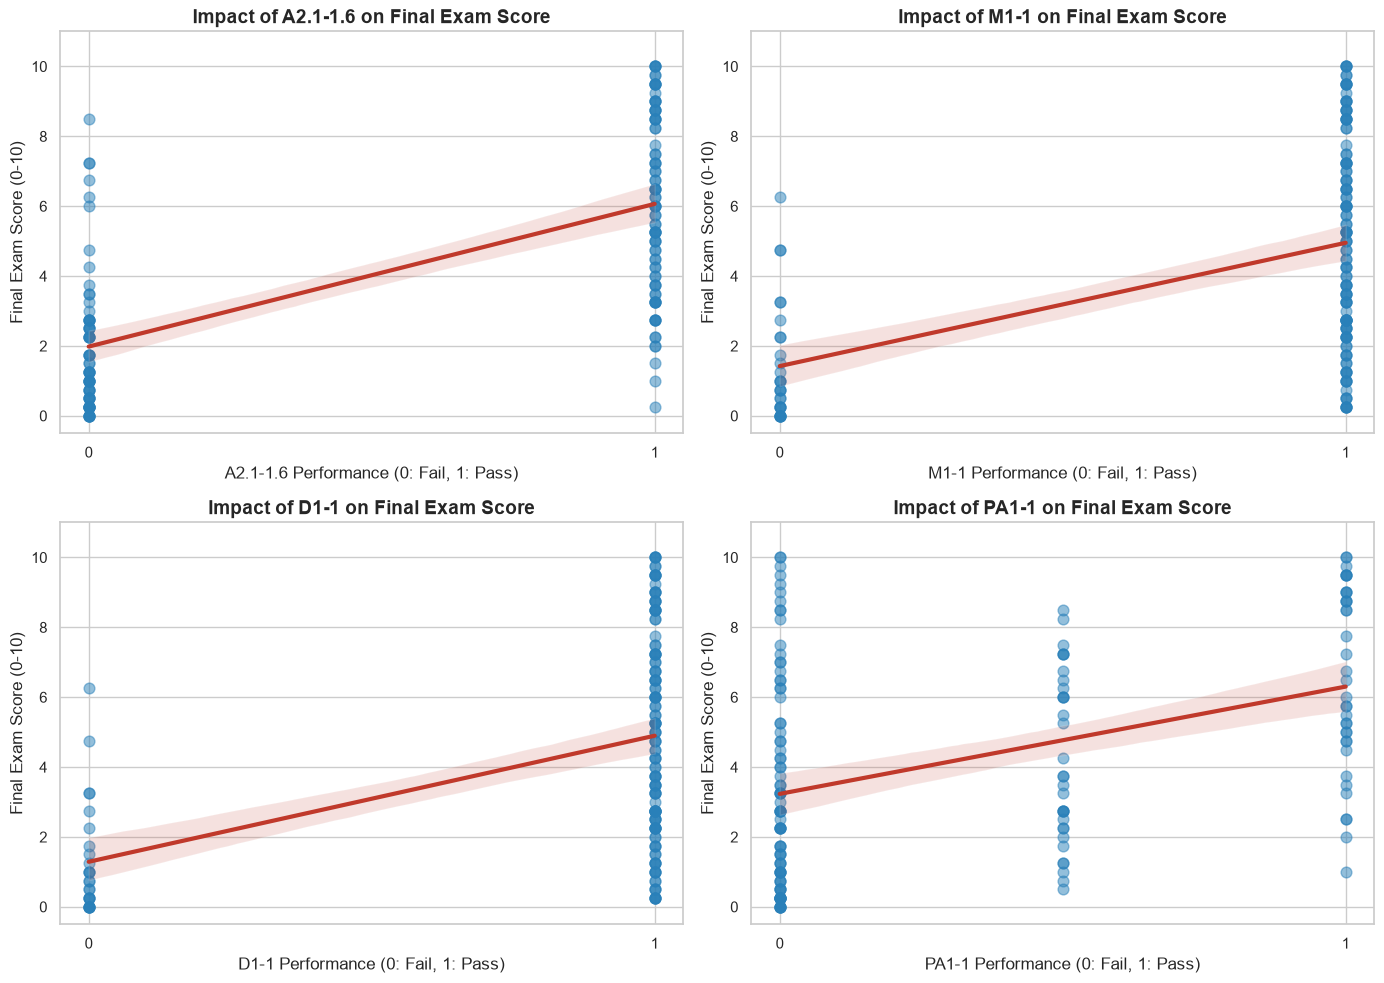

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- VERİ YÜKLEME VE TEMİZLEME ---
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)
# Hatalı veriyi analiz öncesi kaldırıyoruz
df.loc[75, 'A2.1-1.6'] = None 

# --- GÖRSELLEŞTİRME ---
# Odaklanacağımız 4 ana beceri
beceriler = ['A2.1-1.6', 'M1-1', 'D1-1', 'PA1-1']

# Grafiğin arka plan stilini ayarlıyoruz
sns.set_theme(style="whitegrid")

# 4 grafik sığacak tuvali açıyoruz
plt.figure(figsize=(14, 10))

# Becerileri tek tek dönüp 4 parçalı (2x2) görseli oluşturuyoruz
for i, beceri in enumerate(beceriler, 1):
    plt.subplot(2, 2, i) 
    
    # Nokta grafiği (Scatter) ve kırmızı Eğilim Çizgisini (Regression) çizdiriyoruz
    sns.regplot(data=df, x=beceri, y='Nota Examen', 
                scatter_kws={'alpha': 0.5, 'color': '#2980b9', 's': 60}, 
                line_kws={'color': '#c0392b', 'linewidth': 3})
    
    # Başlıklar ve Eksen İsimlendirmeleri (TAMAMEN İNGİLİZCE)
    plt.title(f"Impact of {beceri} on Final Exam Score", fontsize=14, fontweight='bold')
    plt.xlabel(f"{beceri} Performance (0: Fail, 1: Pass)", fontsize=12)
    plt.ylabel("Final Exam Score (0-10)", fontsize=12)
    
    # Eksenleri düzgün göstermek için sabitliyoruz
    plt.xticks([0, 1]) 
    plt.ylim(-0.5, 11) 

# Grafikleri tuvale orantılı bir şekilde yayıyoruz
plt.tight_layout()

# Ekrana basıyoruz
plt.show()

TOP 5 DRIVERS OF THE FINAL EXAM SCORE


=== A2.1-1.6 Becerisinin En Yakın Dostları (En Yüksek Korelasyon) ===
A2.1-1.5    0.531240
M2.1-3      0.510944
A2.1-2.1    0.484276
R2.1-1      0.482919
A2.1-1.3    0.473303
Name: A2.1-1.6, dtype: float64

=== FİNAL NOTUNU (Nota Examen) En Çok Etkileyen İlk 5 Beceri ===
Nota Ejercicio 5    0.897378
Nota Ejercicio 4    0.760118
PA2.1-4             0.754653
PA1-5               0.734245
R2.1-1              0.722893
Name: Nota Examen, dtype: float64


/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/325791742.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_corr.values, y=top_5_corr.index, palette='viridis')


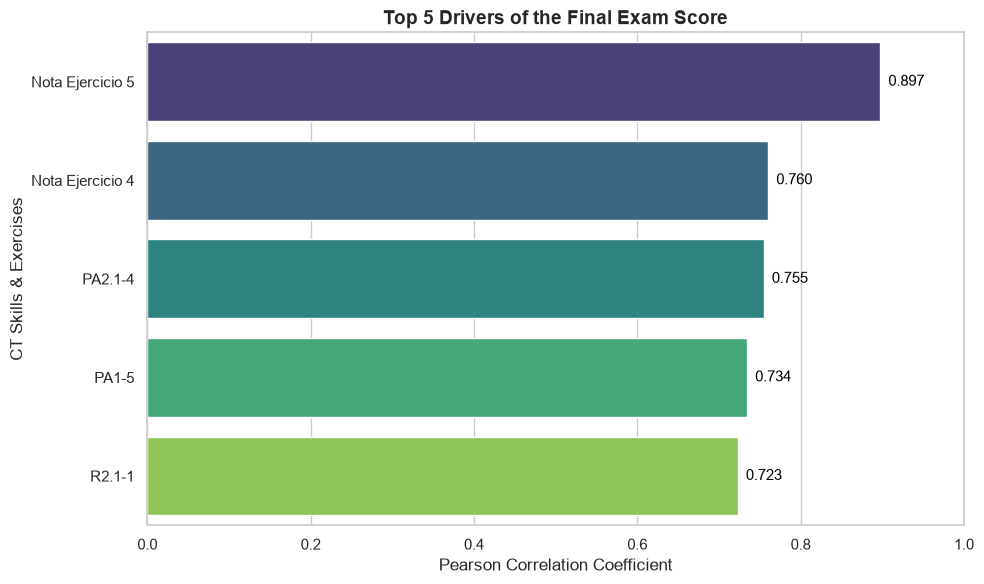

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz ve sayısal değerleri alıyoruz
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# Sadece sayısal verileri alıyoruz
df_sayisal = df.select_dtypes(include=['float64', 'int64'])

# Korelasyon matrisini hesaplatıyoruz
korelasyon_matrisi = df_sayisal.corr()

print("\n=== A2.1-1.6 Becerisinin En Yakın Dostları (En Yüksek Korelasyon) ===")
if 'A2.1-1.6' in korelasyon_matrisi.columns:
    print(korelasyon_matrisi['A2.1-1.6'].sort_values(ascending=False).iloc[1:6])

print("\n=== FİNAL NOTUNU (Nota Examen) En Çok Etkileyen İlk 5 Beceri ===")
if 'Nota Examen' in korelasyon_matrisi.columns:
    print(korelasyon_matrisi['Nota Examen'].sort_values(ascending=False).iloc[1:6])

# Final notunu (Nota Examen) en çok etkileyen ilk 5'i alıyoruz
top_5_corr = korelasyon_matrisi['Nota Examen'].sort_values(ascending=False).iloc[1:6]

# --- GRAFİK ÇİZİM AŞAMASI ---
plt.figure(figsize=(10, 6))

# Seaborn ile yatay çubuk grafiği 
sns.barplot(x=top_5_corr.values, y=top_5_corr.index, palette='viridis')

# Grafiğe başlık ve eksen isimleri ekliyoruz
plt.title('Top 5 Drivers of the Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('CT Skills & Exercises', fontsize=12)

# Korelasyon değeri 0 ile 1 arasında olduğu için X eksenini 0 ile 1 arasında sabitliyoruz
plt.xlim(0, 1.0)

# Çubukların yanına tam rakamları yazdırıyoruz (Okuması kolay olsun diye)
for index, value in enumerate(top_5_corr.values):
    plt.text(value + 0.01, index, f'{value:.3f}', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

TEACHER PERCEPTION VERSUS DATA REALITY

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/2949476658.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grafik_verisi.values, y=grafik_verisi.index, palette=renk_paleti)


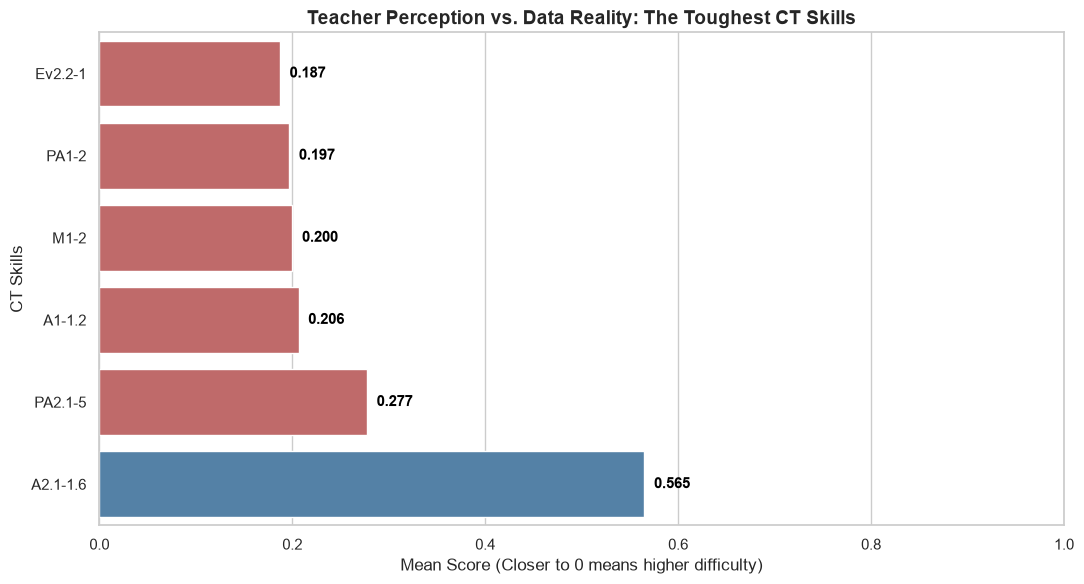

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme ve Düzeltme
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan # Hatalı 10'u siliyoruz

# 2. Sadece Sayısal Verileri Alma
df_sayisal = df.select_dtypes(include=['float64', 'int64'])
beceri_ortalamalari = df_sayisal.mean()

# 3. Veri Temizliği (Beceri olmayan Metadata sütunlarını çıkarıyoruz)
istemeyen_sutunlar = ['Aj1', 'J1', 'CONVOCATORIAS', 'CHICO = 0    CHICA = 1']
beceri_ortalamalari = beceri_ortalamalari.drop(labels=[col for col in istemeyen_sutunlar if col in beceri_ortalamalari.index])

# 4. Gerçekten En Zor 5 Beceri (Ortalaması en düşük olanlar)
en_zor_5 = beceri_ortalamalari.sort_values(ascending=True).head(5)

# 5. A2.1-1.6 verisi
a2_1_6_ortalama = beceri_ortalamalari['A2.1-1.6']

# 6. Grafik için verileri birleştirme
grafik_verisi = pd.concat([en_zor_5, pd.Series({'A2.1-1.6': a2_1_6_ortalama})])

# 7. GÖRSELLEŞTİRME
plt.figure(figsize=(11, 6))

# En zor 5 beceri için Kırmızı, A2.1-1.6 için Mavi renk kullanıyoruz
renk_paleti = ['indianred'] * 5 + ['steelblue']

ax = sns.barplot(x=grafik_verisi.values, y=grafik_verisi.index, palette=renk_paleti)

plt.title('Teacher Perception vs. Data Reality: The Toughest CT Skills', fontsize=14, fontweight='bold')
plt.xlabel('Mean Score (Closer to 0 means higher difficulty)', fontsize=12)
plt.ylabel('CT Skills', fontsize=12)
plt.xlim(0, 1.0)

# Barların yanına tam değerleri yazdıralım
for index, value in enumerate(grafik_verisi.values):
    ax.text(value + 0.01, index, f"{value:.3f}", color='black', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

FINAL EXAM AND ALGORITHMIC THINKING PERFORMANCE BY LANGUAGE OF INSTRUCTION

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/850083321.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Language', y='Nota Examen', ax=axes[0], palette="Set2")
/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/850083321.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Language', y='PA1-1', ax=axes[1], palette="Set3")


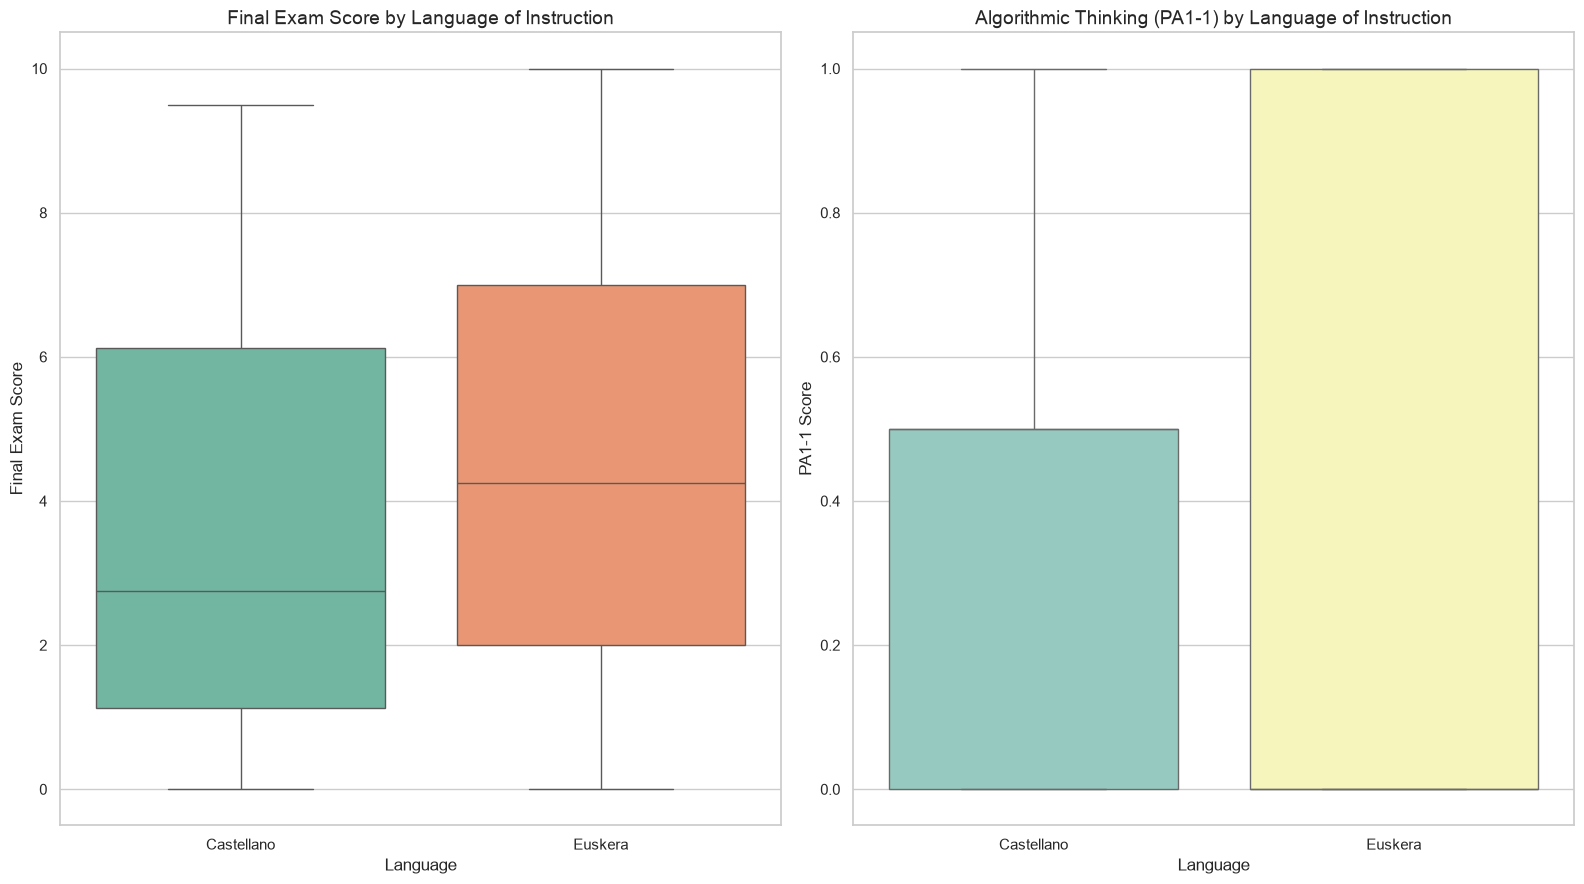

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. VERİ YÜKLEME ---
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# --- 2. VERİ HAZIRLIĞI (Dil Ayrımı) ---
# GRUPO sütununu inceleyerek eğitim dilini belirliyoruz:
def belirle_dil(grup):
    grup_str = str(grup)
    if '02' in grup_str:
        return 'Castellano'
    elif '31' in grup_str or '32' in grup_str:
        return 'Euskera'
    return None

# 'Language' adında yeni bir sütun oluşturuyoruz
df['Language'] = df['GRUPO'].apply(belirle_dil)

# --- 3. GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Sol Grafik: Final Exam Score
sns.boxplot(data=df, x='Language', y='Nota Examen', ax=axes[0], palette="Set2")
axes[0].set_title('Final Exam Score by Language of Instruction', fontsize=14)
axes[0].set_xlabel('Language', fontsize=12)
axes[0].set_ylabel('Final Exam Score', fontsize=12)

# Sağ Grafik: Algorithmic Thinking / PA1-1 Score
sns.boxplot(data=df, x='Language', y='PA1-1', ax=axes[1], palette="Set3")
axes[1].set_title('Algorithmic Thinking (PA1-1) by Language of Instruction', fontsize=14)
axes[1].set_xlabel('Language', fontsize=12)
axes[1].set_ylabel('PA1-1 Score', fontsize=12)

plt.tight_layout()
plt.show()

FINAL EXAM SCORE DISTRIBUTION ACROSS SPECIFIC GROUPS

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/3242486042.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Group_Short', y='Nota Examen', palette='Set1', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])


Grupların Final Notu İstatistikleri:
                              mean  median  count
GRUPO                                            
02 (Castellano - Mañana)  3.730392   2.750     51
31 (Euskera - Mañana)     5.741071   6.125     56
32 (Euskera - Mañana)     3.197917   2.625     48


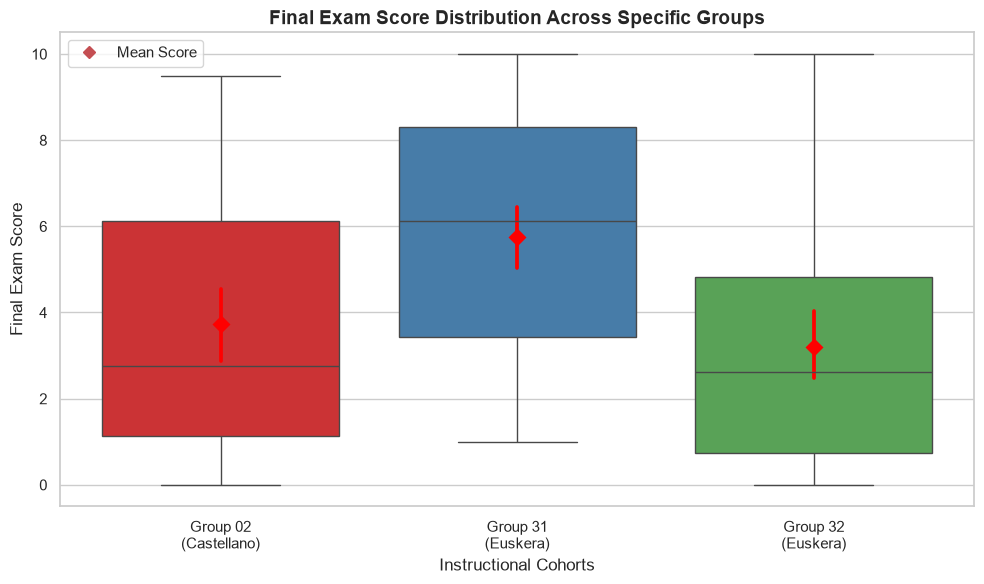

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# Gruplara göre Final Sınavı (Nota Examen) ortalamalarını ve ortancalarını hesaplıyoruz
print("Grupların Final Notu İstatistikleri:")
print(df.groupby('GRUPO')['Nota Examen'].agg(['mean', 'median', 'count']))

# X ekseninde isimler çok uzun durup birbirine girmesin diye kısaltıyoruz
grup_isimleri = {
    '02 (Castellano - Mañana)': 'Group 02\n(Castellano)',
    '31 (Euskera - Mañana)': 'Group 31\n(Euskera)',
    '32 (Euskera - Mañana)': 'Group 32\n(Euskera)'
}
df['Group_Short'] = df['GRUPO'].map(grup_isimleri)

# Grafiği çizmeye başlıyoruz
plt.figure(figsize=(10, 6))

# Kutuları çizdiriyoruz (dağılımı ve ortancayı gösterir)
sns.boxplot(data=df, x='Group_Short', y='Nota Examen', palette='Set1', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])

# Ortalamaları (mean) kırmızı elmas şekliyle kutuların üzerine ekliyoruz
sns.pointplot(data=df, x='Group_Short', y='Nota Examen', estimator='mean', color='red', markers='D', linestyles='', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])

# Grafiği isimlendiriyoruz
plt.title('Final Exam Score Distribution Across Specific Groups', fontsize=14, fontweight='bold')
plt.xlabel('Instructional Cohorts', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)

# Kırmızı elmasın ne anlama geldiğini gösteren küçük bir not ekliyoruz
plt.plot([], [], 'rD', label='Mean Score')
plt.legend()

plt.tight_layout()
plt.show()

CORRELATION MATRICES OF ALGORITHMIC THINKING AND ABSTRACTION SKILLS

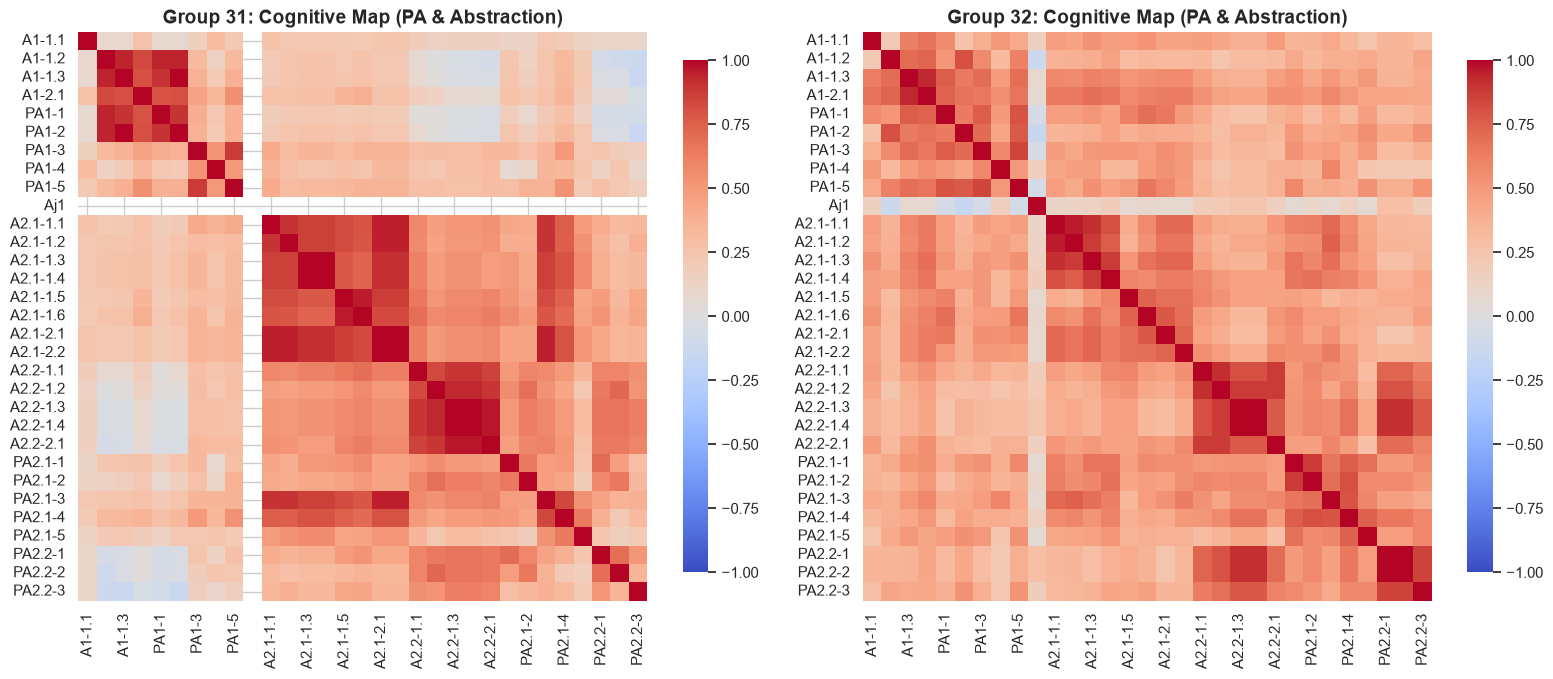

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# Hatalı 10 verisini temizliyoruz
df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

# Sadece PA (Algoritma) ve A (Soyutlama) becerilerini alıyoruz
hedef_sutunlar = [col for col in df.columns if str(col).startswith(('PA', 'A')) and col != 'ASIGNATURA']

# 31 ve 32 gruplarını ayırıyoruz
df_31 = df[df['GRUPO'] == '31 (Euskera - Mañana)'][hedef_sutunlar].apply(pd.to_numeric, errors='coerce')
df_32 = df[df['GRUPO'] == '32 (Euskera - Mañana)'][hedef_sutunlar].apply(pd.to_numeric, errors='coerce')

# İki grubun korelasyonlarını ayrı ayrı hesaplıyoruz
corr_31 = df_31.corr()
corr_32 = df_32.corr()

# Yan yana iki Heatmap çizdiriyoruz
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grup 31 Haritası
sns.heatmap(corr_31, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[0].set_title('Group 31: Cognitive Map (PA & Abstraction)', fontsize=14, fontweight='bold')

# Grup 32 Haritası
sns.heatmap(corr_32, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[1].set_title('Group 32: Cognitive Map (PA & Abstraction)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

PERFORMANCE BY ENGINEERING MAJOR (FINAL EXAM SCORE) - THE UNDERDOG EFFECT

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/2348400889.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TITULACIÓN', y='Nota Examen', palette='viridis')


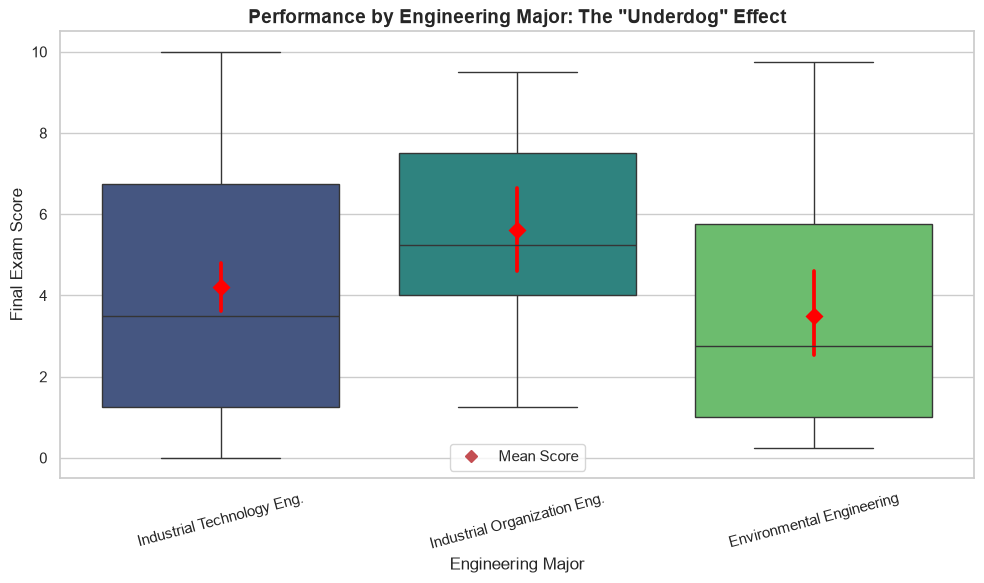

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# --- İNGİLİZCE VERİ ÇEVİRİSİ ---
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

plt.figure(figsize=(10, 6))

# Kutuları çizdiriyoruz
sns.boxplot(data=df, x='TITULACIÓN', y='Nota Examen', palette='viridis')

# Ortalamaları (mean) kırmızı elmas şekliyle kutuların üzerine ekliyoruz
sns.pointplot(data=df, x='TITULACIÓN', y='Nota Examen', estimator='mean', color='red', markers='D', linestyles='')

# Grafiği isimlendiriyoruz
plt.title('Performance by Engineering Major: The "Underdog" Effect', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Major', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)

# İsimler uzunsa birbirine girmesin diye hafif eğik yazdırıyoruz
plt.xticks(rotation=15) 

# Kırmızı elmasın ne anlama geldiğini gösteren küçük bir not ekliyoruz
plt.plot([], [], 'rD', label='Mean Score')
plt.legend()

plt.tight_layout()
plt.show()

ALGORITHMIC THINKING BY ENGINEERING MAJOR

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/586376431.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TITULACIÓN', y='PA1-1', palette='viridis')


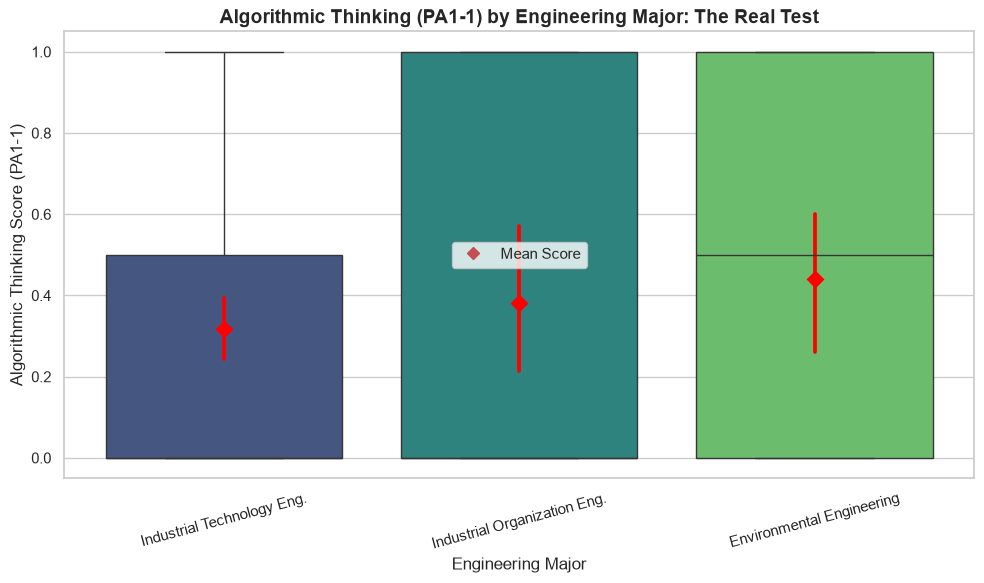

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# --- İNGİLİZCE VERİ ÇEVİRİSİ ---
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='TITULACIÓN', y='PA1-1', palette='viridis')
sns.pointplot(data=df, x='TITULACIÓN', y='PA1-1', estimator='mean', color='red', markers='D', linestyles='')

plt.title('Algorithmic Thinking (PA1-1) by Engineering Major: The Real Test', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Major', fontsize=12) 
plt.ylabel('Algorithmic Thinking Score (PA1-1)', fontsize=12)
plt.xticks(rotation=15) 

plt.plot([], [], 'rD', label='Mean Score')
plt.legend()
plt.tight_layout()
plt.show()

COGNITIVE MAPPING AND HIDDEN PROFILES

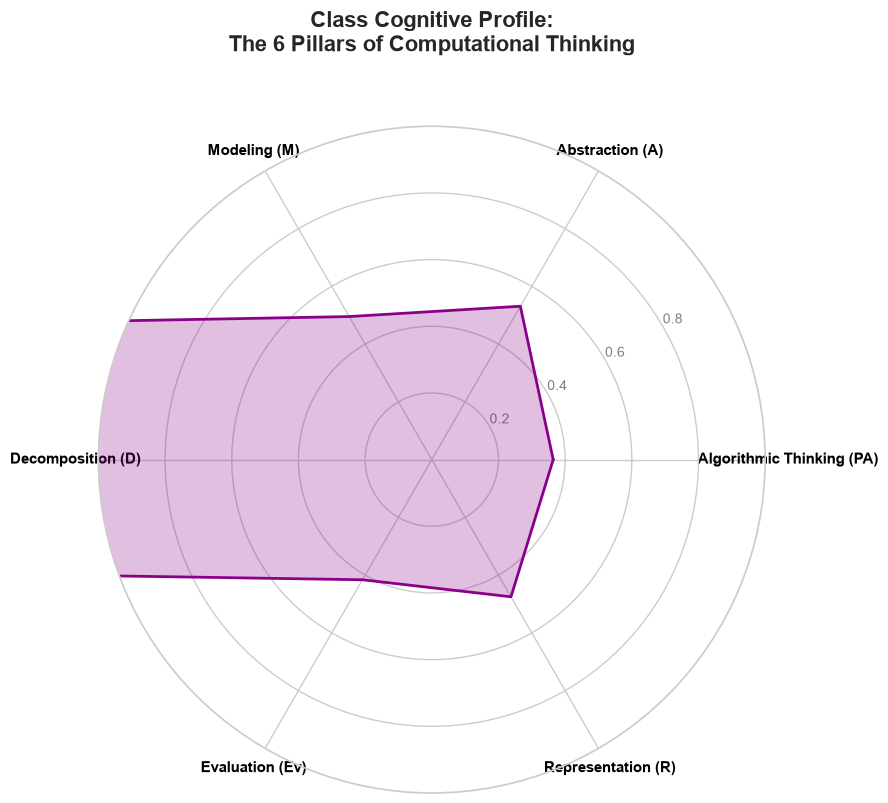

=== MAKRO CT BECERİLERİ GENEL ORTALAMASI ===
Decomposition (D): 23.223
Abstraction (A): 0.531
Modeling (M): 0.496
Representation (R): 0.475
Evaluation (Ev): 0.416
Algorithmic Thinking (PA): 0.364


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. Veri Yükleme ve Hata Temizliği
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

# Metadata'yı atalım 
istemeyen_sutunlar = ['Aj1', 'J1', 'CONVOCATORIAS', 'CHICO = 0    CHICA = 1', 'ASIGNATURA']
for col in istemeyen_sutunlar:
    if col in df.columns:
        df = df.drop(columns=[col])

df_sayisal = df.select_dtypes(include=['float64', 'int64'])

# 2. Bütün Sütunları 6 Ana Kategoriye Gruplama
kategoriler = {
    'Algorithmic Thinking (PA)': [],
    'Abstraction (A)': [],
    'Modeling (M)': [],
    'Decomposition (D)': [],
    'Evaluation (Ev)': [],
    'Representation (R)': []
}

for col in df_sayisal.columns:
    col_str = str(col)
    if col_str.startswith('PA'):
        kategoriler['Algorithmic Thinking (PA)'].append(col)
    elif col_str.startswith('Ev'):
        kategoriler['Evaluation (Ev)'].append(col)
    elif col_str.startswith('R'):
        kategoriler['Representation (R)'].append(col)
    elif col_str.startswith('M'):
        kategoriler['Modeling (M)'].append(col)
    elif col_str.startswith('D'):
        kategoriler['Decomposition (D)'].append(col)
    elif col_str.startswith('A'): 
        kategoriler['Abstraction (A)'].append(col)

# 3. Her Kategori İçin Genel CT Ortalamasını Hesaplama
kategori_ortalamalari = {}
for kat, sutunlar in kategoriler.items():
    if len(sutunlar) > 0:
        kategori_ortalamalari[kat] = df_sayisal[sutunlar].mean().mean()

# 4. GÖRSELLEŞTİRME: Radar Grafiği 
kategori_isimleri = list(kategori_ortalamalari.keys())
degerler = list(kategori_ortalamalari.values())

degerler += degerler[:1]
aci_sayisi = len(kategori_isimleri)
acilar = [n / float(aci_sayisi) * 2 * pi for n in range(aci_sayisi)]
acilar += acilar[:1]

# Grafiği Çizdirme
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

plt.xticks(acilar[:-1], kategori_isimleri, color='black', size=11, fontweight='bold')
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
plt.ylim(0, 1)

# Alanı mor renk ile dolduruyoruz
ax.plot(acilar, degerler, linewidth=2, linestyle='solid', color='darkmagenta')
ax.fill(acilar, degerler, 'darkmagenta', alpha=0.25)

plt.title("Class Cognitive Profile:\nThe 6 Pillars of Computational Thinking", size=16, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

# Terminale sayısal verileri de yazdıralım
print("=== MAKRO CT BECERİLERİ GENEL ORTALAMASI ===")
for k, v in sorted(kategori_ortalamalari.items(), key=lambda item: item[1], reverse=True):
    print(f"{k}: {v:.3f}")

COGNITIVE PROFILES AND COGNITIVE DNA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Veri Yükleme ve Temizlik
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)
df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

beceri_sutunlari = [col for col in df.columns if str(col).startswith(('PA', 'A', 'M', 'D', 'Ev', 'R')) and col != 'ASIGNATURA']
df_analiz = df[beceri_sutunlari].apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. Makine Öğrenmesi (K-Means & PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analiz)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analiz['Cluster_Name'] = 'Profile ' + (kmeans.fit_predict(X_scaled) + 1).astype(str)

# ---> İSİMLENDİRME İNGİLİZCEYE ÇEVRİLDİ <---
profil_isimleri = {
    'Profile 1': 'Mainstream / Practitioners',
    'Profile 2': 'Critical Risk Group',
    'Profile 3': 'Conceptual Leaders (System Thinkers)'
}
df_analiz['Cluster_Name'] = df_analiz['Cluster_Name'].map(profil_isimleri)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_analiz['PCA1'] = X_pca[:, 0]
df_analiz['PCA2'] = X_pca[:, 1]

# 3. Kognitif DNA Hazırlığı (Makro Beceriler)
kategoriler = {
    'PA (Algorithmic)': [col for col in df_analiz.columns if col.startswith('PA')],
    'A (Abstraction)': [col for col in df_analiz.columns if col.startswith('A')],
    'M (Modeling)': [col for col in df_analiz.columns if col.startswith('M')],
    'D (Decomposition)': [col for col in df_analiz.columns if col.startswith('D') and not col.startswith('DNI')],
    'Ev (Evaluation)': [col for col in df_analiz.columns if col.startswith('Ev')],
    'R (Representation)': [col for col in df_analiz.columns if col.startswith('R')]
}

for isim, sutunlar in kategoriler.items():
    if len(sutunlar) > 0:
        df_analiz[isim] = df_analiz[sutunlar].mean(axis=1)

profil_ozeti = df_analiz.groupby('Cluster_Name')[list(kategoriler.keys())].mean()

# 4. TEK FİGÜRDE İKİ GRAFİK (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Sol Grafik: PCA Dağılımı ---
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df_analiz, palette='Set1', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('Spatial Distribution of Cognitive Profiles (PCA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component 1 (General CT Variance)')
axes[0].set_ylabel('Principal Component 2 (Specific Skill Divergence)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Cognitive Profiles') 

# --- Sağ Grafik: Zihinsel DNA Isı Haritası ---
sns.heatmap(profil_ozeti, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title('Cognitive DNA: Skill Breakdown per Profile', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Identified Profiles')
axes[1].set_xlabel('Macro CT Skills')
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

GENDER SUCCESS CORRELATION

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/1746034527.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Nota Examen', palette=['#3498db', '#e74c3c'])
/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_19238/1746034527.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='PA1-1', palette=['#3498db', '#e74c3c'])


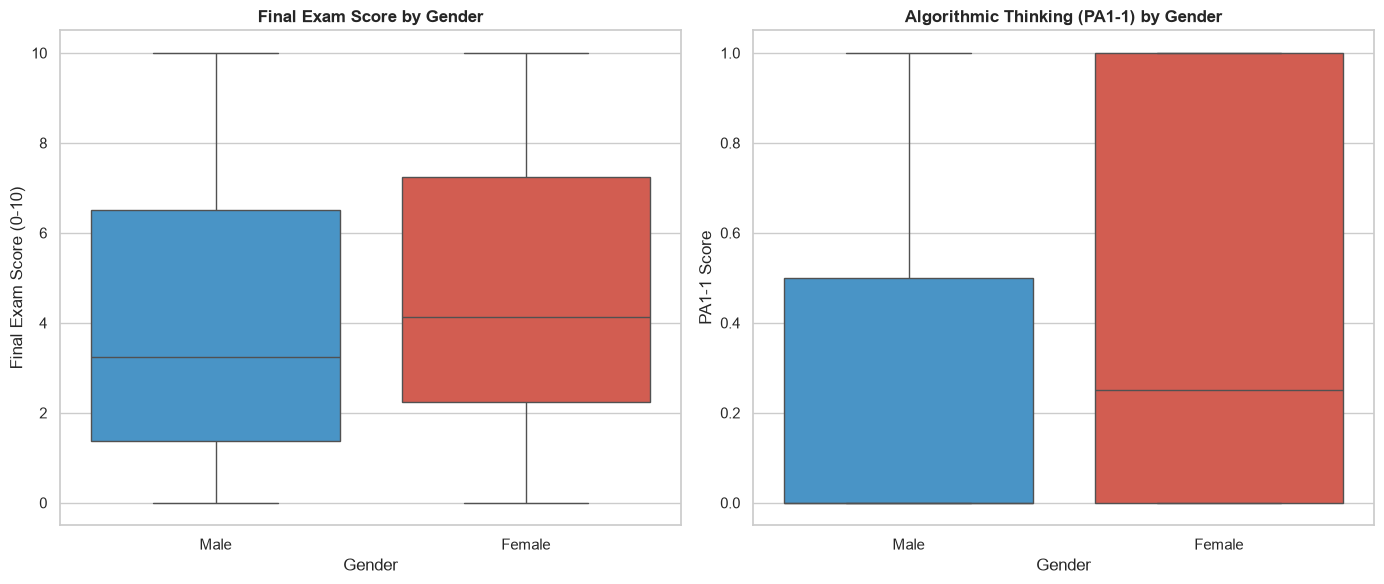

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- VERİ YÜKLEME ---
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# Cinsiyet sütununu otomatik bulma 
cinsiyet_sutun_adaylari = [col for col in df.columns if 'CHICO' in str(col).upper()]
cinsiyet_sutunu = cinsiyet_sutun_adaylari[0] if cinsiyet_sutun_adaylari else None

if cinsiyet_sutunu:
    df['Gender'] = df[cinsiyet_sutunu].map({0.0: 'Male', 1.0: 'Female'})

    # --- CİNSİYET VS. BAŞARI ANALİZİ ---
    plt.figure(figsize=(14, 6))

    # 1. Grafik: Final Notu Karşılaştırması
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='Gender', y='Nota Examen', palette=['#3498db', '#e74c3c'])
    plt.title("Final Exam Score by Gender", fontweight='bold')
    plt.ylabel("Final Exam Score (0-10)")
    plt.xlabel("Gender")

    # 2. Grafik: En Zorlanılan Beceri (PA1-1) Karşılaştırması
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='Gender', y='PA1-1', palette=['#3498db', '#e74c3c'])
    plt.title("Algorithmic Thinking (PA1-1) by Gender", fontweight='bold')
    plt.ylabel("PA1-1 Score")
    plt.xlabel("Gender")

    plt.tight_layout()
    plt.show()
else:
    print("Gender column not found, check Excel headers!")

GENDER GAP ANALYSIS - COGNITIVE DIFFERENCES

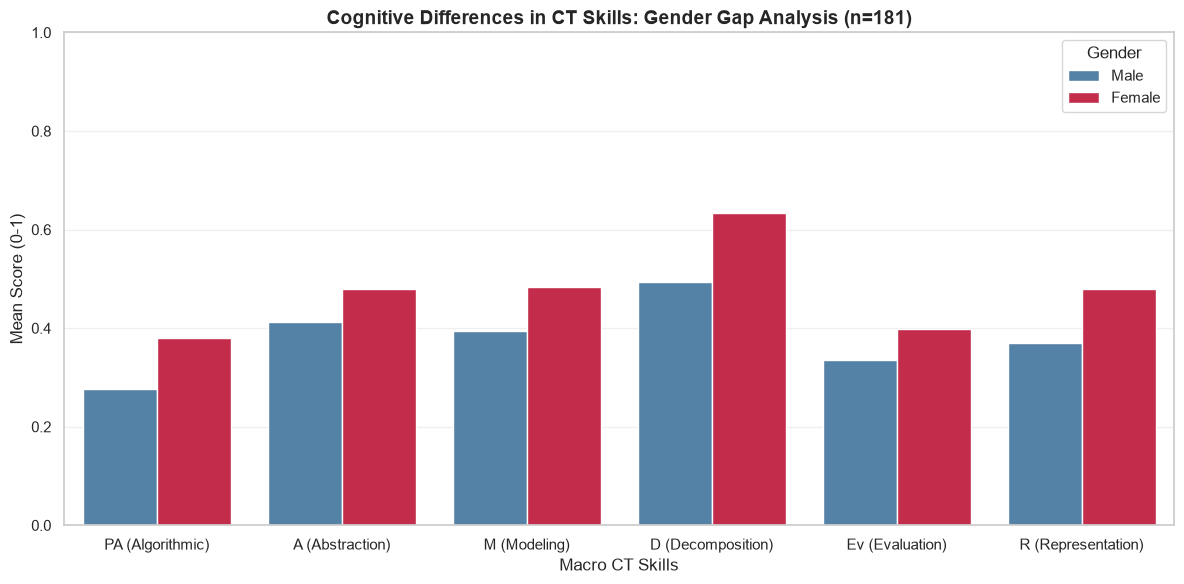

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veri Yükleme
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

# 2. Cinsiyet Sütununu Hazırlama
cinsiyet_sutunu = 'CHICO = 0    CHICA = 1'
df = df.dropna(subset=[cinsiyet_sutunu]) 

# ---> SADECE İNGİLİZCE KALACAK ŞEKİLDE GÜNCELLENDİ <---
df['Gender'] = df[cinsiyet_sutunu].map({0: 'Male', 1: 'Female'})

# 3. Makro Becerilerin Gruplanması 
kategoriler = {
    'PA (Algorithmic)': [col for col in df.columns if str(col).startswith('PA')],
    'A (Abstraction)': [col for col in df.columns if str(col).startswith('A') and col != 'ASIGNATURA'],
    'M (Modeling)': [col for col in df.columns if str(col).startswith('M')],
    'D (Decomposition)': [col for col in df.columns if str(col).startswith('D') and not str(col).startswith('DNI')],
    'Ev (Evaluation)': [col for col in df.columns if str(col).startswith('Ev')],
    'R (Representation)': [col for col in df.columns if str(col).startswith('R')]
}

# 4. Ortalama Puanların Hesaplanması 
for kat, sutunlar in kategoriler.items():
    if len(sutunlar) > 0:
        df[kat] = df[sutunlar].apply(pd.to_numeric, errors='coerce').fillna(0).mean(axis=1)

# 5. Görselleştirme için Veriyi Dönüştürme (Melt)
plot_data = df[['Gender'] + list(kategoriler.keys())].melt(id_vars='Gender', var_name='Skill', value_name='Score')

# 6. Grafiği Çizdirme
plt.figure(figsize=(12, 6))

# ---> PALET İSİMLERİ YENİ İNGİLİZCE FORMATLA EŞLEŞTİRİLDİ <---
sns.barplot(data=plot_data, x='Skill', y='Score', hue='Gender', palette={'Male': 'steelblue', 'Female': 'crimson'}, errorbar=None)

plt.title('Cognitive Differences in CT Skills: Gender Gap Analysis (n=181)', fontsize=14, fontweight='bold')
plt.xlabel('Macro CT Skills', fontsize=12)
plt.ylabel('Mean Score (0-1)', fontsize=12)
plt.ylim(0, 1) 
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()